In [1]:
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("./annotations/bundle_annotations.csv", engine='python')

kc_cols = ['Syntax-Ontology_Expert', 'Educational-Ontology_Expert', 'AST_Parser', 'Syntax-Ontology_LLM', 'Educational-Ontology_LLM', 'Free-Form_LLM']

for col in kc_cols:
    data[col] = (
        data[col]
        .fillna("")
        .apply(lambda x: x.split(",") if x != "" else [])
    )
data.head(3)

,individual_name,bundle_name,type,topic,Syntax-Ontology_Expert,Educational-Ontology_Expert,AST_Parser,Syntax-Ontology_LLM,Educational-Ontology_LLM,Free-Form_LLM
0,py_display_time1,py_time_conversion,PCEX Example,Variables and Operations,"[print, IntegerLiteral, int, input, BinaryOper...","[TransformingToIntType, FindRemainder, Assigni...","[Assign, Mod, Constant, Call, FloorDiv]","[ArithmeticExpression, ArtithmeticOperator, As...","[ArithmeticOperation, AssigningVariable, Calli...","[input and output operations, variable manipul..."
1,py_display_time2,py_time_conversion,PCEX Challenge,Variables and Operations,"[print, IntegerLiteral, int, input, BinaryOper...","[TransformingToIntType, FindRemainder, Assigni...","[Assign, Mod, Constant, Call, FloorDiv]","[ArithmeticExpression, ArtithmeticOperator, As...","[ArithmeticOperation, AssigningVariable, Calli...","[function call, input and output operations, v..."
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,PCEX Example,Variables and Operations,"[print, IntegerLiteral, int, input, BinaryOper...","[Multiplication, TransformingToIntType, Additi...","[Assign, Constant, Mult, Add, Call, Div]","[ArithmeticExpression, ArtithmeticOperator, As...","[Addition, ArithmeticOperation, AssigningVaria...","[input and output operations, variable manipul..."


Total bundles: 52
Activities per bundle (count -> number of bundles):
count
2    36
3    13
4     3
Activities by type:
type
PCEX Challenge    71
PCEX Example      52


<Axes: xlabel='count'>

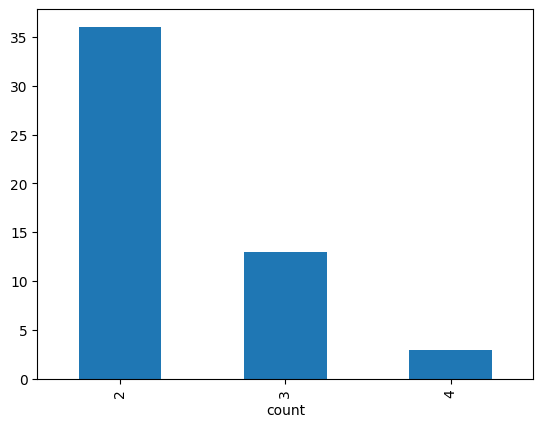

In [2]:
vc = data["bundle_name"].value_counts().sort_index()
dist = vc.value_counts().sort_index()

print(f"Total bundles: {data['bundle_name'].nunique()}")
print("Activities per bundle (count -> number of bundles):")
print(dist.to_string())

print("Activities by type:")
print(data["type"].value_counts().to_string())

dist.plot.bar()

In [3]:
def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 1
    return len(a & b) / len(a | b)

pairwise_jaccard = {}

for kc_col in kc_cols:
    rows = []
    for bundle_name, group in data.groupby("bundle_name"):
        lists = group[kc_col].tolist()
        idxs = group.index.tolist()
        for (i, list1), (j, list2) in combinations(zip(idxs, lists), 2):
            rows.append({
                "bundle_name": bundle_name,
                "item1": i,
                "item2": j,
                "jaccard": jaccard(list1, list2)
            })
    pairwise_jaccard[kc_col] = pd.DataFrame(rows)

In [4]:
for kc_col in kc_cols:
    print(f"\n=== {kc_col} ===")
    summary = (
        pairwise_jaccard[kc_col]
        .groupby("bundle_name")["jaccard"]
        .agg(["mean", "median", "min", "max", "count"])
        .reset_index()
    )
    display(summary)


=== Syntax-Ontology_Expert ===


,bundle_name,mean,median,min,max,count
0,objects_classes_account,0.857143,0.857143,0.857143,0.857143,1
1,objects_classes_loan,0.857143,0.857143,0.857143,0.857143,1
2,objects_classes_point,0.769231,0.769231,0.769231,0.769231,1
3,objects_classes_tv,1.000000,1.000000,1.000000,1.000000,1
4,py_bmi_calculator,0.900000,0.900000,0.900000,0.900000,1
5,py_char_dict,0.590909,0.590909,0.590909,0.590909,1
6,py_check_adjacent,0.764706,0.764706,0.705882,0.823529,3
7,py_check_age,0.833333,0.833333,0.833333,0.833333,1
8,py_check_product_code,0.739130,0.739130,0.739130,0.739130,1
9,py_concat_char_two_str,0.800000,0.800000,0.800000,0.800000,1



=== Educational-Ontology_Expert ===


,bundle_name,mean,median,min,max,count
0,objects_classes_account,0.812500,0.812500,0.812500,0.812500,1
1,objects_classes_loan,0.833333,0.833333,0.833333,0.833333,1
2,objects_classes_point,0.800000,0.800000,0.800000,0.800000,1
3,objects_classes_tv,0.937500,0.937500,0.937500,0.937500,1
4,py_bmi_calculator,0.800000,0.800000,0.800000,0.800000,1
5,py_char_dict,0.520000,0.520000,0.520000,0.520000,1
6,py_check_adjacent,0.694444,0.700000,0.583333,0.800000,3
7,py_check_age,0.722222,0.722222,0.722222,0.722222,1
8,py_check_product_code,0.888889,0.888889,0.888889,0.888889,1
9,py_concat_char_two_str,0.700000,0.700000,0.700000,0.700000,1



=== AST_Parser ===


...

,bundle_name,mean,median,min,max,count
0,objects_classes_account,0.975610,0.975610,0.975610,0.975610,1
1,objects_classes_loan,0.000000,0.000000,0.000000,0.000000,1
2,objects_classes_point,0.880000,0.880000,0.880000,0.880000,1
3,objects_classes_tv,0.000000,0.000000,0.000000,0.000000,1
4,py_bmi_calculator,0.900000,0.900000,0.900000,0.900000,1
5,py_char_dict,0.600000,0.600000,0.600000,0.600000,1
6,py_check_adjacent,0.791544,0.806452,0.750000,0.818182,3
7,py_check_age,0.877551,0.877551,0.877551,0.877551,1
8,py_check_product_code,0.837209,0.837209,0.837209,0.837209,1
9,py_concat_char_two_str,0.750000,0.750000,0.750000,0.750000,1



=== Educational-Ontology_LLM ===


,bundle_name,mean,median,min,max,count
0,objects_classes_account,0.750000,0.750000,0.750000,0.750000,1
1,objects_classes_loan,0.648649,0.648649,0.648649,0.648649,1
2,objects_classes_point,0.840000,0.840000,0.840000,0.840000,1
3,objects_classes_tv,0.000000,0.000000,0.000000,0.000000,1
4,py_bmi_calculator,0.809524,0.809524,0.809524,0.809524,1
5,py_char_dict,0.617021,0.617021,0.617021,0.617021,1
6,py_check_adjacent,0.770158,0.758621,0.700000,0.851852,3
7,py_check_age,0.714286,0.714286,0.714286,0.714286,1
8,py_check_product_code,0.906977,0.906977,0.906977,0.906977,1
9,py_concat_char_two_str,0.826087,0.826087,0.826087,0.826087,1



=== Free-Form_LLM ===


,bundle_name,mean,median,min,max,count
0,objects_classes_account,0.625000,0.625000,0.625000,0.625000,1
1,objects_classes_loan,0.625000,0.625000,0.625000,0.625000,1
2,objects_classes_point,1.000000,1.000000,1.000000,1.000000,1
3,objects_classes_tv,0.600000,0.600000,0.600000,0.600000,1
4,py_bmi_calculator,1.000000,1.000000,1.000000,1.000000,1
5,py_char_dict,0.777778,0.777778,0.777778,0.777778,1
6,py_check_adjacent,1.000000,1.000000,1.000000,1.000000,3
7,py_check_age,0.909091,0.909091,0.909091,0.909091,1
8,py_check_product_code,0.888889,0.888889,0.888889,0.888889,1
9,py_concat_char_two_str,1.000000,1.000000,1.000000,1.000000,1


In [5]:
for kc_col in kc_cols:
    print(f"\n=== {kc_col} ===")
    overall_summary = pairwise_jaccard[kc_col]["jaccard"].agg(
        ["mean", "median", "min", "max", "count"]
    )
    display(overall_summary)


=== Syntax-Ontology_Expert ===


mean       0.847010
median     0.875000
min        0.583333
max        1.000000
count     93.000000
Name: jaccard, dtype: float64


=== Educational-Ontology_Expert ===


mean       0.845915
median     0.869565
min        0.368421
max        1.000000
count     93.000000
Name: jaccard, dtype: float64


=== AST_Parser ===


...

mean       0.858933
median     0.892857
min        0.000000
max        1.000000
count     93.000000
Name: jaccard, dtype: float64


=== Educational-Ontology_LLM ===


mean       0.823818
median     0.843750
min        0.000000
max        1.000000
count     93.000000
Name: jaccard, dtype: float64


=== Free-Form_LLM ===


mean       0.825787
median     0.857143
min        0.333333
max        1.000000
count     93.000000
Name: jaccard, dtype: float64

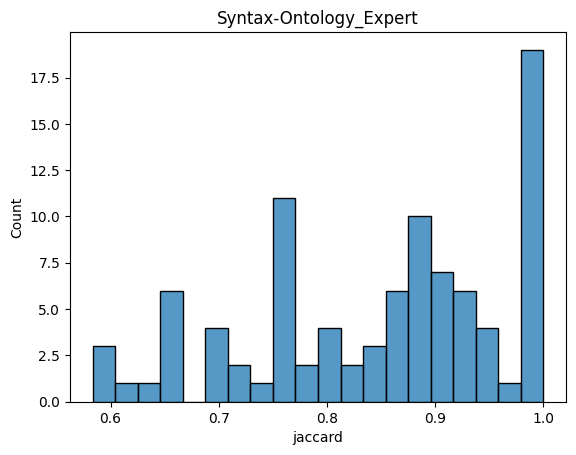

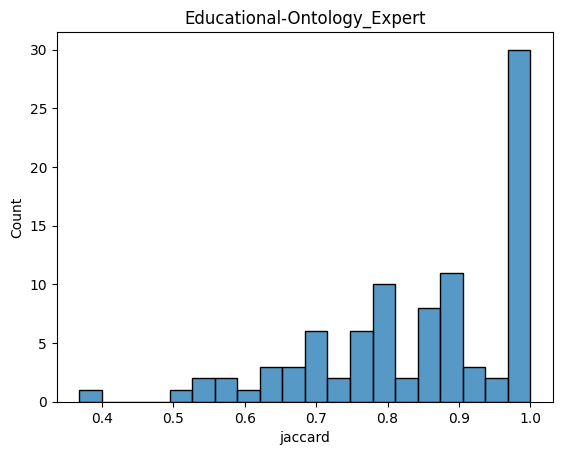

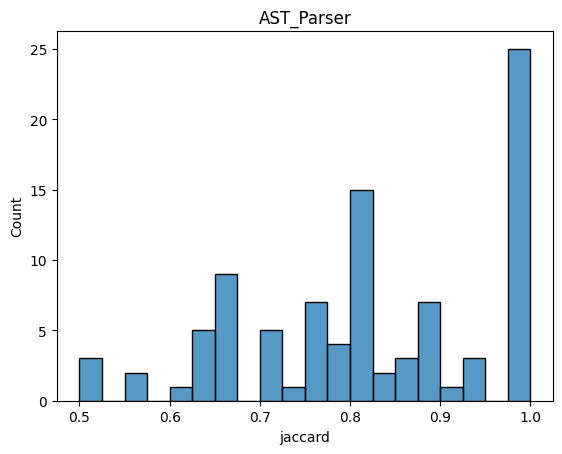

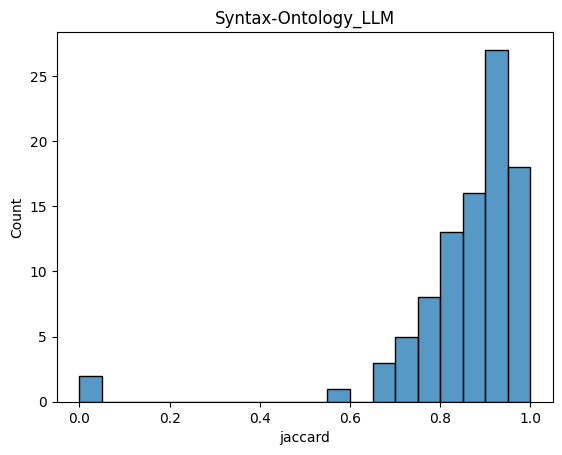

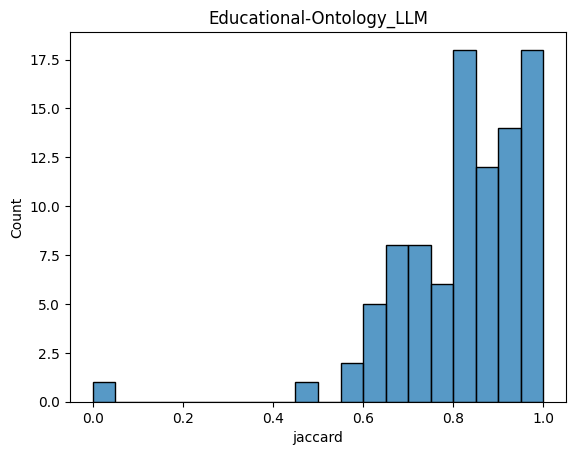

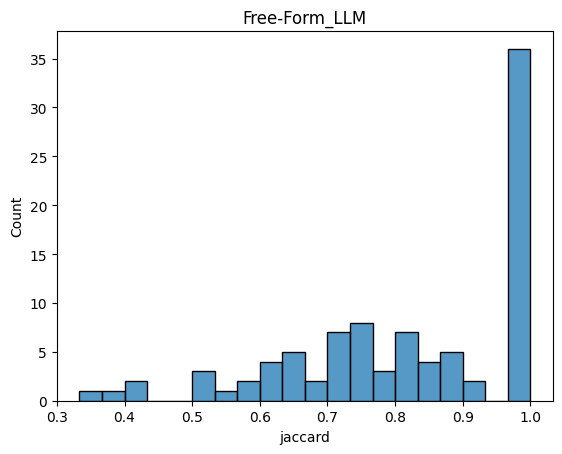

In [6]:
for kc_col in kc_cols:
    plt.figure()
    sns.histplot(pairwise_jaccard[kc_col]["jaccard"], bins=20)
    plt.title(kc_col)
    plt.show()

In [7]:
from sklearn.preprocessing import MultiLabelBinarizer

kc_matrices = {}

for kc_col in kc_cols:
    mlb = MultiLabelBinarizer()
    X = mlb.fit_transform(data[kc_col])
    kc_matrices[kc_col] = pd.DataFrame(X, columns=mlb.classes_, index=data.index)

In [8]:
import numpy as np

idf_dict = {}

for kc_col in kc_cols:
    kc_matrix = kc_matrices[kc_col]
    N = kc_matrix.shape[0]
    ni = kc_matrix.sum(axis=0)
    idf_dict[kc_col] = np.log(N / ni)

In [9]:
weighted_matrices = {}

for kc_col in kc_cols:
    weighted_matrices[kc_col] = kc_matrices[kc_col] * idf_dict[kc_col]

In [10]:
from sklearn.preprocessing import normalize

normalized_matrices = {}

for kc_col in kc_cols:
    normalized_matrices[kc_col] = normalize(weighted_matrices[kc_col])

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_matrices = {}

for kc_col in kc_cols:
    cosine_matrices[kc_col] = cosine_similarity(normalized_matrices[kc_col])

In [12]:
cosine_pairs = {}

for kc_col in kc_cols:
    cosine_matrix = cosine_matrices[kc_col]
    rows = []
    for i, j in combinations(range(len(data)), 2):
        rows.append({
            "item1": data.index[i],
            "item2": data.index[j],
            "cosine": cosine_matrix[i, j],
            "set1": data.loc[data.index[i], "bundle_name"],
            "set2": data.loc[data.index[j], "bundle_name"]
        })
    cosine_pairs[kc_col] = pd.DataFrame(rows)

In [13]:
for kc_col in kc_cols:
    within = cosine_pairs[kc_col][cosine_pairs[kc_col]["set1"] == cosine_pairs[kc_col]["set2"]]
    print(f"{kc_col}: {within['cosine'].mean():.4f}")

Syntax-Ontology_Expert: 0.8003
Educational-Ontology_Expert: 0.8811
AST_Parser: 0.7445
Syntax-Ontology_LLM: 0.7787
Educational-Ontology_LLM: 0.8191
Free-Form_LLM: 0.8290


In [14]:
for kc_col in kc_cols:
    between = cosine_pairs[kc_col][cosine_pairs[kc_col]["set1"] != cosine_pairs[kc_col]["set2"]]
    print(f"{kc_col}: {between['cosine'].mean():.4f}")

Syntax-Ontology_Expert: 0.1493
Educational-Ontology_Expert: 0.1388
AST_Parser: 0.1505
Syntax-Ontology_LLM: 0.1748
Educational-Ontology_LLM: 0.1660
Free-Form_LLM: 0.2098


In [15]:
# --- Leave-one-out bundle assignment: Jaccard ---
# For each exercise, remove it from its bundle, build bundle KC representations
# from the remaining exercises, and assign the exercise to the most similar bundle.

jaccard_results = {}

for kc_col in kc_cols:
    jaccard_records = []
    for idx, row in data.iterrows():
        exercise = row["individual_name"]
        original_bundle = row["bundle_name"]
        exercise_kcs = set(row[kc_col])

        others = data[data.index != idx]
        bundle_kcs = {
            bundle: set(kc for kcs in group[kc_col] for kc in kcs)
            for bundle, group in others.groupby("bundle_name")
        }

        scores = {bundle: jaccard(exercise_kcs, kcs) for bundle, kcs in bundle_kcs.items()}
        best_bundle = max(scores, key=scores.get)

        jaccard_records.append({
            "exercise": exercise,
            "original_bundle": original_bundle,
            "assigned_bundle": best_bundle,
            "correct": best_bundle == original_bundle,
            "best_score": scores[best_bundle],
            "original_bundle_score": scores.get(original_bundle, 0.0)
        })

    jaccard_results[kc_col] = pd.DataFrame(jaccard_records)
    print(f"\n=== {kc_col} ===")
    print(f"Jaccard accuracy: {jaccard_results[kc_col]['correct'].mean():.3f}")
    display(jaccard_results[kc_col])


=== Syntax-Ontology_Expert ===
Jaccard accuracy: 0.691


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,1.000000,1.000000
1,py_display_time2,py_time_conversion,py_time_conversion,True,1.000000,1.000000
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_f_to_c_conversion,True,1.000000,1.000000
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,1.000000,1.000000
4,py_bmi_calculator1,py_bmi_calculator,py_bmi_calculator,True,0.900000,0.900000
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_list_min_max,False,0.764706,0.647059
119,py_soda_survey_soda_avg,py_soda_survey,py_print_medals,False,0.928571,0.764706
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_print_medals,False,1.000000,0.764706
121,py_three_boolean,py_three_booleans,py_hot_dry,False,0.823529,0.764706



=== Educational-Ontology_Expert ===
Jaccard accuracy: 0.764


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,1.000000,1.00
1,py_display_time2,py_time_conversion,py_time_conversion,True,1.000000,1.00
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_f_to_c_conversion,True,0.700000,0.70
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_vending_machine,False,0.727273,0.70
4,py_bmi_calculator1,py_bmi_calculator,py_bmi_calculator,True,0.800000,0.80
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_soda_survey,True,0.650000,0.65
119,py_soda_survey_soda_avg,py_soda_survey,py_soda_survey,True,0.800000,0.80
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_soda_survey,True,0.850000,0.85
121,py_three_boolean,py_three_booleans,py_fail_course,False,1.000000,1.00



=== AST_Parser ===
Jaccard accuracy: 0.634


...

,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,1.000000,1.000000
1,py_display_time2,py_time_conversion,py_time_conversion,True,1.000000,1.000000
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_f_to_c_conversion,True,0.950000,0.950000
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,0.950000,0.950000
4,py_bmi_calculator1,py_bmi_calculator,py_bmi_calculator,True,0.900000,0.900000
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_list_min_max,False,0.888889,0.675000
119,py_soda_survey_soda_avg,py_soda_survey,py_print_medals,False,0.965517,0.725000
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_print_medals,False,0.875000,0.725000
121,py_three_boolean,py_three_booleans,py_hot_dry,False,0.900000,0.866667



=== Educational-Ontology_LLM ===
Jaccard accuracy: 0.699


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,0.941176,0.941176
1,py_display_time2,py_time_conversion,py_time_conversion,True,0.941176,0.941176
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_bmi_calculator,False,0.818182,0.818182
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,0.818182,0.818182
4,py_bmi_calculator1,py_bmi_calculator,py_bmi_calculator,True,0.809524,0.809524
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_search_list,False,0.674419,0.651163
119,py_soda_survey_soda_avg,py_soda_survey,py_soda_survey,True,0.813953,0.813953
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_soda_survey,True,0.744186,0.744186
121,py_three_boolean,py_three_booleans,py_fail_course,False,0.863636,0.857143



=== Free-Form_LLM ===
Jaccard accuracy: 0.707


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,0.833333,0.833333
1,py_display_time2,py_time_conversion,py_concat_str_num,False,0.833333,0.833333
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_f_to_c_conversion,True,0.666667,0.666667
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,0.666667,0.666667
4,py_bmi_calculator1,py_bmi_calculator,py_bmi_calculator,True,1.000000,1.000000
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_soda_survey,True,1.000000,1.000000
119,py_soda_survey_soda_avg,py_soda_survey,py_soda_survey,True,1.000000,1.000000
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_soda_survey,True,1.000000,1.000000
121,py_three_boolean,py_three_booleans,py_hot_dry,False,0.875000,0.750000


In [16]:
# --- Leave-one-out bundle assignment: Cosine (TF-IDF weighted) ---
# IDF computed over full dataset; exercise vector compared against mean bundle vector
# (excluding the exercise itself).

from sklearn.preprocessing import MultiLabelBinarizer, normalize as sk_normalize
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

cosine_results = {}

for kc_col in kc_cols:
    mlb = MultiLabelBinarizer()
    X = mlb.fit_transform(data[kc_col])
    kc_matrix = pd.DataFrame(X, columns=mlb.classes_, index=data.index)

    N = kc_matrix.shape[0]
    ni = kc_matrix.sum(axis=0).replace(0, 1)
    idf = np.log(N / ni)

    weighted = kc_matrix * idf

    cosine_records = []
    for idx, row in data.iterrows():
        exercise = row["individual_name"]
        original_bundle = row["bundle_name"]

        ex_vec = sk_normalize(weighted.loc[idx].values.reshape(1, -1))

        others = data[data.index != idx]
        bundle_scores = {}
        for bundle, group in others.groupby("bundle_name"):
            bundle_vec = sk_normalize(weighted.loc[group.index].mean(axis=0).values.reshape(1, -1))
            bundle_scores[bundle] = cos_sim(ex_vec, bundle_vec)[0, 0]

        best_bundle = max(bundle_scores, key=bundle_scores.get)

        cosine_records.append({
            "exercise": exercise,
            "original_bundle": original_bundle,
            "assigned_bundle": best_bundle,
            "correct": best_bundle == original_bundle,
            "best_score": bundle_scores[best_bundle],
            "original_bundle_score": bundle_scores.get(original_bundle, 0.0)
        })

    cosine_results[kc_col] = pd.DataFrame(cosine_records)
    print(f"\n=== {kc_col} ===")
    print(f"Cosine accuracy: {cosine_results[kc_col]['correct'].mean():.3f}")
    display(cosine_results[kc_col])


=== Syntax-Ontology_Expert ===
Cosine accuracy: 0.675


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,1.000000,1.000000
1,py_display_time2,py_time_conversion,py_time_conversion,True,1.000000,1.000000
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_f_to_c_conversion,True,1.000000,1.000000
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,1.000000,1.000000
4,py_bmi_calculator1,py_bmi_calculator,py_pythagorean_theorem,False,0.655739,0.418634
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_print_medals,False,0.805927,0.805927
119,py_soda_survey_soda_avg,py_soda_survey,py_print_medals,False,0.999715,0.944511
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_print_medals,False,0.999716,0.943702
121,py_three_boolean,py_three_booleans,py_phone_age,False,0.887921,0.603309



=== Educational-Ontology_Expert ===
Cosine accuracy: 0.715


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,1.000000,1.000000
1,py_display_time2,py_time_conversion,py_time_conversion,True,1.000000,1.000000
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_f_to_c_conversion,True,0.740961,0.740961
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,0.740961,0.740961
4,py_bmi_calculator1,py_bmi_calculator,py_pythagorean_theorem,False,0.817357,0.652709
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_soda_survey,True,0.847012,0.847012
119,py_soda_survey_soda_avg,py_soda_survey,py_soda_survey,True,0.944703,0.944703
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_soda_survey,True,0.938794,0.938794
121,py_three_boolean,py_three_booleans,py_fail_course,False,1.000000,1.000000



=== AST_Parser ===
Cosine accuracy: 0.602


...

,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,1.000000,1.000000
1,py_display_time2,py_time_conversion,py_time_conversion,True,1.000000,1.000000
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_pythagorean_theorem,False,0.840526,0.701106
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,0.701106,0.701106
4,py_bmi_calculator1,py_bmi_calculator,py_pythagorean_theorem,False,0.889306,0.467396
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_print_medals,False,0.875526,0.817610
119,py_soda_survey_soda_avg,py_soda_survey,py_print_medals,False,0.967129,0.925102
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_print_medals,False,0.851454,0.844885
121,py_three_boolean,py_three_booleans,py_phone_age,False,0.862576,0.624216



=== Educational-Ontology_LLM ===
Cosine accuracy: 0.724


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,0.999152,0.999152
1,py_display_time2,py_time_conversion,py_time_conversion,True,0.999152,0.999152
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_f_to_c_conversion,True,0.818333,0.818333
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_f_to_c_conversion,True,0.818333,0.818333
4,py_bmi_calculator1,py_bmi_calculator,py_bmi_calculator,True,0.756008,0.756008
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_print_medals,False,0.787473,0.723315
119,py_soda_survey_soda_avg,py_soda_survey,py_soda_survey,True,0.927176,0.927176
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_soda_survey,True,0.914068,0.914068
121,py_three_boolean,py_three_booleans,py_fail_course,False,0.856095,0.816713



=== Free-Form_LLM ===
Cosine accuracy: 0.634


,exercise,original_bundle,assigned_bundle,correct,best_score,original_bundle_score
0,py_display_time1,py_time_conversion,py_time_conversion,True,0.789089,0.789089
1,py_display_time2,py_time_conversion,py_concat_str_num,False,0.985705,0.789089
2,py_celsius_to_fahrenheit,py_f_to_c_conversion,py_if_else_num,False,0.638683,0.135484
3,py_fahrenheit_to_celsius,py_f_to_c_conversion,py_time_conversion,False,0.182995,0.135484
4,py_bmi_calculator1,py_bmi_calculator,py_bmi_calculator,True,1.000000,1.000000
...,...,...,...,...,...,...
118,py_soda_survey_soda_max,py_soda_survey,py_soda_survey,True,1.000000,1.000000
119,py_soda_survey_soda_avg,py_soda_survey,py_soda_survey,True,1.000000,1.000000
120,py_soda_survey_soda_respondent_avg,py_soda_survey,py_soda_survey,True,1.000000,1.000000
121,py_three_boolean,py_three_booleans,py_hot_dry,False,0.820272,0.569935


In [17]:
# --- Summary comparison ---
for kc_col in kc_cols:
    print(f"\n=== {kc_col} ===")
    summary = pd.DataFrame({
        "metric": ["Jaccard", "Cosine (TF-IDF)"],
        "accuracy": [
            jaccard_results[kc_col]["correct"].mean(),
            cosine_results[kc_col]["correct"].mean()
        ],
        "correct": [
            jaccard_results[kc_col]["correct"].sum(),
            cosine_results[kc_col]["correct"].sum()
        ],
        "total": [len(jaccard_results[kc_col]), len(cosine_results[kc_col])]
    })
    display(summary)


=== Syntax-Ontology_Expert ===


,metric,accuracy,correct,total
0,Jaccard,0.691057,85,123
1,Cosine (TF-IDF),0.674797,83,123



=== Educational-Ontology_Expert ===


,metric,accuracy,correct,total
0,Jaccard,0.764228,94,123
1,Cosine (TF-IDF),0.715447,88,123



=== AST_Parser ===


...

,metric,accuracy,correct,total
0,Jaccard,0.642276,79,123
1,Cosine (TF-IDF),0.577236,71,123



=== Educational-Ontology_LLM ===


,metric,accuracy,correct,total
0,Jaccard,0.699187,86,123
1,Cosine (TF-IDF),0.723577,89,123



=== Free-Form_LLM ===


,metric,accuracy,correct,total
0,Jaccard,0.707317,87,123
1,Cosine (TF-IDF),0.634146,78,123
